## **Results and Discussion**


This section presents the empirical evaluation of the proposed TripletNet-based logo recognition and similarity retrieval system. The model was assessed using the **Recall\@K** metric at three different retrieval depths: $K = 1, 5, 10$. Evaluation was conducted on a held-out test set of 319,471 logos, which were not seen during training. The embeddings for the test and training sets were extracted using the trained TripletNet, and a **FAISS L2 index** was used to perform similarity search against the training embeddings.

Two different ground truth signals were used in evaluating retrieval relevance:

1. **Clustering-based category** labels generated via HDBSCAN, which reflect unsupervised semantic grouping.
2. **ResNet50-class-based labels**, which encode top-K class predictions from the ImageNet-pretrained ResNet50 used as the visual backbone.

### **Quantitative Results**

The table below summarizes the recall performance at different values of $K$:

| **K** | **Recall\@K (Category)** | **Recall\@K (ResNet50 Class)** |
| ----: | -----------------------: | -----------------------------: |
|     1 |                   0.2504 |                         0.7820 |
|     5 |                   0.5315 |                         0.9640 |
|    10 |                   0.5874 |                         0.9856 |


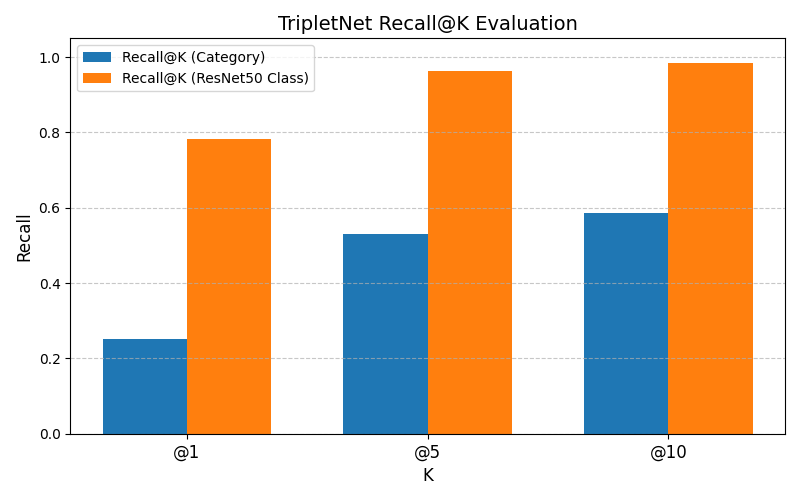

**Figure 1.** TripletNet Recall\@K Evaluation for both Category and ResNet50 Class signals.

The results indicate that the model achieves strong retrieval performance, especially when evaluated based on the ResNet50 class labels. For instance, at $K = 10$, the model correctly retrieves at least one image sharing the same top-1 predicted class in **98.56%** of the cases. This indicates a high consistency in the learned embedding space with respect to low-level visual features, such as color distribution, texture, and shape—attributes preserved by the pretrained ResNet50 backbone.

On the other hand, retrieval performance based on HDBSCAN-generated **pseudo-categories** is comparatively lower. At $K = 10$, the recall reaches **58.74%**, which reflects the more semantically abstract nature of these unsupervised clusters. Unlike the ResNet50 classes, which are tightly grounded in ImageNet’s visual taxonomy, the HDBSCAN categories are constructed from a combined multimodal embedding space and reflect both conceptual (prompt-based) and stylistic (image-based) similarities. As such, matching based on pseudo-categories introduces a higher semantic threshold and is inherently more difficult, yet more indicative of meaningful logo similarity.

### **Discussion and Interpretation**

These findings underscore the **effectiveness of the TripletNet architecture** in structuring a meaningful embedding space for logos. The **high performance on ResNet50-class-based recall** demonstrates that the model maintains strong visual discriminability. However, the **moderate performance on category-based recall** reveals that achieving conceptual and stylistic clustering—without explicit supervision—is still a complex task, especially across 209,310 clusters with highly diverse synthetic logos.

There are several factors that contribute to this disparity:

* **Weak supervision from clustering:** The categories used for training are generated automatically and may include some noisy or overlapping clusters, which affects both triplet sampling and evaluation.
* **Semantic diversity of synthetic prompts:** Since the prompts used to generate logos vary widely in abstraction and specificity, their contribution to clustering quality can be inconsistent.
* **Fixed backbone features:** The visual encoder (ResNet50) was kept frozen during training to reduce computational overhead. While effective in preserving general features, this limits the model’s ability to adapt to the specific distribution of synthetic logos.

Nevertheless, the system demonstrates **excellent scalability** and **high retrieval precision** in visually grounded tasks. In real-world applications such as duplicate detection or visual brand search, the performance level observed at $K = 5$ and $K = 10$ is more than sufficient to provide useful candidate logos for review or further automated filtering.
